# FEATURE ENGINEERING
Notebook ini merupakan tahap lanjutan dari proses Data Wrangling yang bertujuan untuk melakukan Feature Engineering dengan menambahkan kolom "Need_Want_Label" sebagai fitur baru yang mengklasifikasikan setiap transaksi keuangan ke dalam kategori Need (Kebutuhan) atau Want (Keinginan). 

## IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATA

In [2]:
df = pd.read_csv('data_cleaned.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2733 entries, 0 to 2732
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              2733 non-null   str    
 1   Category          2733 non-null   str    
 2   Transaction Type  2733 non-null   str    
 3   Amount_IDR        2733 non-null   float64
 4   Macro_Category    2733 non-null   str    
dtypes: float64(1), str(4)
memory usage: 217.3 KB


,Date,Category,Transaction Type,Amount_IDR,Macro_Category
0,2018-09-20,Transportation,Expense,6244.298246,Transportation
1,2018-09-20,Food,Expense,12488.596491,Food & Beverage
2,2018-09-19,subscription,Expense,41420.511696,Lifestyle & Entertainment
3,2018-09-17,subscription,Expense,3954.722222,Lifestyle & Entertainment
4,2018-09-16,Festivals,Expense,52243.961988,Lifestyle & Entertainment


## ANALISIS OUTLIER

In [3]:
expense_df = df[df['Transaction Type'] == 'Expense']

Q1 = expense_df['Amount_IDR'].quantile(0.25)
Q3 = expense_df['Amount_IDR'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = expense_df[
    (expense_df['Amount_IDR'] < lower_bound) | 
    (expense_df['Amount_IDR'] > upper_bound)]

print('=== STATISTIK DESKRIPTIF Amount_IDR (Expense) ===')
print(expense_df['Amount_IDR'].describe().apply(lambda x: f'{x:,.0f}'))
print(f'\nIQR              : Rp {IQR:,.0f}')
print(f'Lower Bound      : Rp {lower_bound:,.0f}')
print(f'Upper Bound      : Rp {upper_bound:,.0f}')
print(f'\nJumlah Outlier   : {len(outliers)} baris ({len(outliers)/len(expense_df)*100:.2f}% dari total expense)')

=== STATISTIK DESKRIPTIF Amount_IDR (Expense) ===
count          2,563
mean         425,343
std        3,735,423
min              396
25%            8,219
50%           34,110
75%          191,061
max      128,938,000
Name: Amount_IDR, dtype: str

IQR              : Rp 182,841
Lower Bound      : Rp -266,043
Upper Bound      : Rp 465,322

Jumlah Outlier   : 360 baris (14.05% dari total expense)


**Insight:** Kami memutuskan untuk tidak menghapus outliers karena nilai-nilai ekstrem tersebut berisi pembayaran sewa (Mortgage & Rent) yang bersifat periodik dan biaya renovasi (Home Improvement) yang bersifat insidental. Nilai-nilai tersebut merepresentasikan transaksi yang valid secara dominan. Penghapusan outliers akan berakibat pada hilangnya informasi yang relevan dan berisiko menciptakan bias ke arah underestimation pengeluaran.

## FEATURE ENGINEERING (Need & Want Label)


In [4]:
# melihat kategori pada kolom 'Macro_Category'
print('=== KATEGORI Macro_Category ===')
print(df['Macro_Category'].value_counts())

=== KATEGORI Macro_Category ===
Macro_Category
Food & Beverage              1146
Lifestyle & Entertainment     384
Housing & Utilities           367
Transportation                346
Others                        207
Income & Rewards              150
Health & Personal Care        133
Name: count, dtype: int64


In [5]:
need_want_mapping = {
    'Food & Beverage': 'Need',
    'Lifestyle & Entertainment': 'Want',
    'Transportation': 'Need',
    'Housing & Utilities': 'Need',
    'Health & Personal Care': 'Need',
    'Others' : 'Unclassified',
    'Income & Rewards' : 'Income',
}

df['Need_Want_Label'] = df['Macro_Category'].map(need_want_mapping)

# validasi hasil mapping
print('=== VALIDASI MAPPING Need_Want_Label ===')
print(f'Missing/NaN setelah mapping: {df["Need_Want_Label"].isnull().sum()}')
print()
print('=== KATEGORI Need_Want_Label ===')
print(df['Need_Want_Label'].value_counts())

=== VALIDASI MAPPING Need_Want_Label ===
Missing/NaN setelah mapping: 0

=== KATEGORI Need_Want_Label ===
Need_Want_Label
Need            1992
Want             384
Unclassified     207
Income           150
Name: count, dtype: int64


**Insight:** 
- Klasifikasi pada feature engineering dilakukan berdasarkan 2 referensi utama, yaitu:
1. *Warren & Tyagi (2005)** dalam *All Your Worth: The Ultimate Lifetime Money Plan* — mendefinisikan **Needs** sebagai pengeluaran yang tidak dapat dihindari (50% dari pendapatan) dan **Wants** sebagai pengeluaran diskresioner (30% dari pendapatan).
2. **OJK (2023)** dalam *Strategi Nasional Literasi Keuangan Indonesia* — mendefinisikan kebutuhan pangan sebagai komponen primer pengeluaran rumah tangga tanpa membedakan tempat konsumsinya.

- Klasifikasi `Food & Beverage` sebagai Need dilakukan pada level `Macro_Category` mengikuti pendekatan agregasi, dengan pertimbangan bahwa data tidak memiliki granularitas yang cukup untuk memisahkan konsumsi pangan esensial dari konsumsi pangan rekreasional. Keterbatasan ini diakui sebagai limitasi analisis.

In [6]:
# Cross-check: setiap Macro_Category hanya memiliki satu label
print('=== CROSS-CHECK: Macro_Category vs Need_Want_Label ===')
cross_check = df.groupby(['Macro_Category', 'Need_Want_Label']).size().reset_index(name='Jumlah Baris')
print(cross_check.to_string(index=False))

=== CROSS-CHECK: Macro_Category vs Need_Want_Label ===
           Macro_Category Need_Want_Label  Jumlah Baris
          Food & Beverage            Need          1146
   Health & Personal Care            Need           133
      Housing & Utilities            Need           367
         Income & Rewards          Income           150
Lifestyle & Entertainment            Want           384
                   Others    Unclassified           207
           Transportation            Need           346


In [7]:
# Proporsi berdasarkan jumlah transaksi (Expense only)
expense_labeled = df[df['Transaction Type'] == 'Expense']

proporsi_count = expense_labeled['Need_Want_Label'].value_counts(normalize=True).mul(100).round(2)
print('=== PROPORSI BERDASARKAN JUMLAH TRANSAKSI (Expense only) ===')
print(proporsi_count)
print()

# Proporsi berdasarkan nilai transaksi (Amount_IDR)
proporsi_amount = expense_labeled.groupby('Need_Want_Label')['Amount_IDR'].sum()
proporsi_amount_pct = (proporsi_amount / proporsi_amount.sum() * 100).round(2)
print('=== PROPORSI BERDASARKAN NILAI TRANSAKSI (Expense only) ===')
print(proporsi_amount_pct)

=== PROPORSI BERDASARKAN JUMLAH TRANSAKSI (Expense only) ===
Need_Want_Label
Need            77.72
Want            14.98
Unclassified     7.30
Name: proportion, dtype: float64

=== PROPORSI BERDASARKAN NILAI TRANSAKSI (Expense only) ===
Need_Want_Label
Need            87.80
Unclassified     3.13
Want             9.07
Name: Amount_IDR, dtype: float64


**Insight:** Pengecekan pada proporsi dilakukan hanya pada baris Transaction_Type = 'Expense' untuk memastikan bahwa perbandingan Need vs Want tidak terdistorsi oleh baris Income.

## VISUALISASI Need_Want_Label

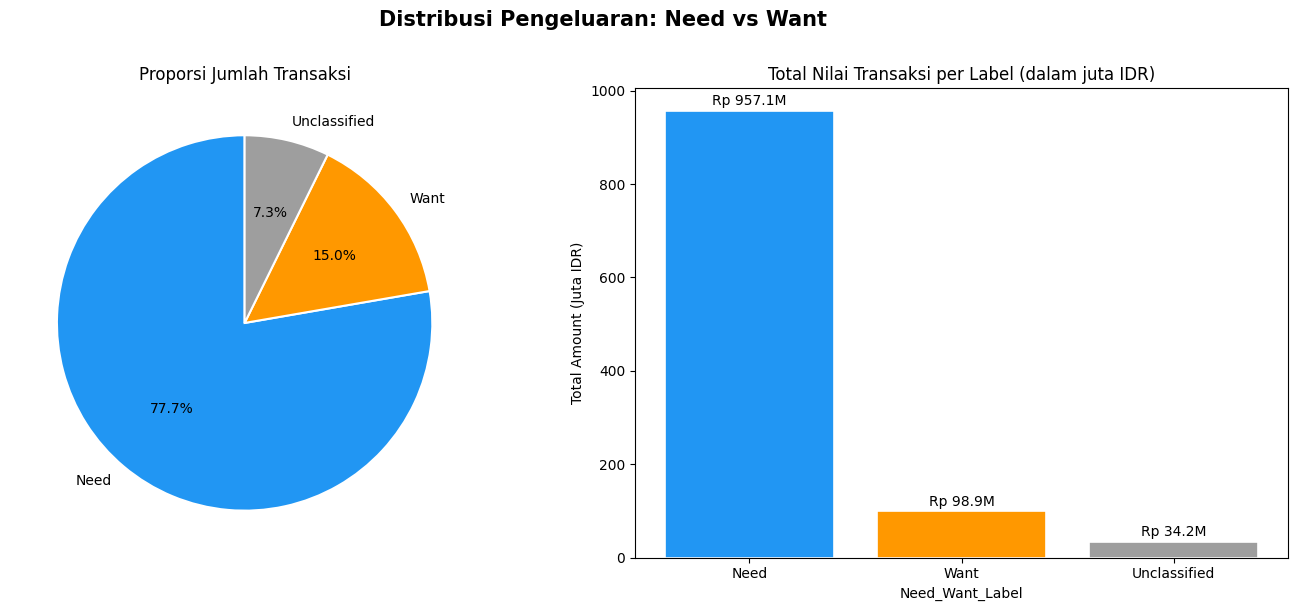

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Pengeluaran: Need vs Want', fontsize=15, fontweight='bold', y=1.01)

palette = {'Need': '#2196F3', 'Want': '#FF9800', 'Unclassified': '#9E9E9E'}
expense_plot = expense_labeled[expense_labeled['Need_Want_Label'] != 'Income']

# Plot 1: Pie chart proporsi jumlah transaksi
count_data = expense_plot['Need_Want_Label'].value_counts()
colors = [palette.get(l, '#9E9E9E') for l in count_data.index]
axes[0].pie(
    count_data,
    labels=count_data.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Proporsi Jumlah Transaksi', fontsize=12)

# Plot 2: Bar chart total nilai transaksi
amount_data = expense_plot.groupby('Need_Want_Label')['Amount_IDR'].sum().sort_values(ascending=False)
bar_colors = [palette.get(l, '#9E9E9E') for l in amount_data.index]
bars = axes[1].bar(amount_data.index, amount_data.values / 1e6, color=bar_colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Total Nilai Transaksi per Label (dalam juta IDR)', fontsize=12)
axes[1].set_xlabel('Need_Want_Label')
axes[1].set_ylabel('Total Amount (Juta IDR)')
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'Rp {bar.get_height():.1f}M',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.savefig('need_want_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## INTERPRETASI HASIL
- Hasil analisis menunjukkan bahwa proporsi pengeluaran Need lebih mendominasi baik dari sisi nilai transaksi maupun jumlah transaksi. 
- Dominasi Need mencerminkan karakteristik dataset yang didominasi data rumah tangga (~77,7% dari total data) yang mencatat lebih banyak pengeluaran untuk kebutuhan pokok dibanding pengeluaran untuk memenuhi gaya hidup.
- Proporsi Need yang mendominasi juga menunjukkan bahwa pengguna lebih banyak mengalokasikan sebagian besar anggaran untuk kebutuhan dasar. Pola ini sangat relevan untuk dijadikan dasar fitur rekomendasi keuangan pada produk Track Smart, Split Easy.

In [9]:
# menyimpan dataset final
df.to_csv('data_final.csv', index=False)
df.head()

,Date,Category,Transaction Type,Amount_IDR,Macro_Category,Need_Want_Label
0,2018-09-20,Transportation,Expense,6244.298246,Transportation,Need
1,2018-09-20,Food,Expense,12488.596491,Food & Beverage,Need
2,2018-09-19,subscription,Expense,41420.511696,Lifestyle & Entertainment,Want
3,2018-09-17,subscription,Expense,3954.722222,Lifestyle & Entertainment,Want
4,2018-09-16,Festivals,Expense,52243.961988,Lifestyle & Entertainment,Want
